# Phase 1: Exploratory Data Analysis
Instacart Market Basket Analysis — Grocery Reorder Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')

DATA = Path('../data')
RESULTS = Path('../results')
RESULTS.mkdir(exist_ok=True)

## 2.1  Dataset Summary Statistics

In [2]:
orders        = pd.read_csv(DATA / 'orders.csv')
prior         = pd.read_csv(DATA / 'order_products__prior.csv')
train         = pd.read_csv(DATA / 'order_products__train.csv')
products      = pd.read_csv(DATA / 'products.csv')
aisles        = pd.read_csv(DATA / 'aisles.csv')
departments   = pd.read_csv(DATA / 'departments.csv')

print('orders        :', orders.shape)
print('prior         :', prior.shape)
print('train         :', train.shape)
print('products      :', products.shape)
print('aisles        :', aisles.shape)
print('departments   :', departments.shape)

orders        : (3421083, 7)
prior         : (32434489, 4)
train         : (1384617, 4)
products      : (49688, 4)
aisles        : (134, 2)
departments   : (21, 2)


In [3]:
n_users   = orders['user_id'].nunique()
n_orders  = len(orders)
n_products = products['product_id'].nunique()

prior_orders = orders[orders['eval_set'] == 'prior']
train_orders = orders[orders['eval_set'] == 'train']

print(f'Total users              : {n_users:,}')
print(f'Total orders             : {n_orders:,}')
print(f'Unique products          : {n_products:,}')
print(f'Prior orders             : {len(prior_orders):,}')
print(f'Train orders (labels)    : {len(train_orders):,}')
print(f'Prior product rows       : {len(prior):,}')
print(f'Train product rows       : {len(train):,}')

Total users              : 206,209
Total orders             : 3,421,083
Unique products          : 49,688
Prior orders             : 3,214,874
Train orders (labels)    : 131,209
Prior product rows       : 32,434,489
Train product rows       : 1,384,617


Orders per user (prior):
count    206209.00
mean         15.59
std          16.65
min           3.00
25%           5.00
50%           9.00
75%          19.00
max          99.00
Name: order_id, dtype: float64


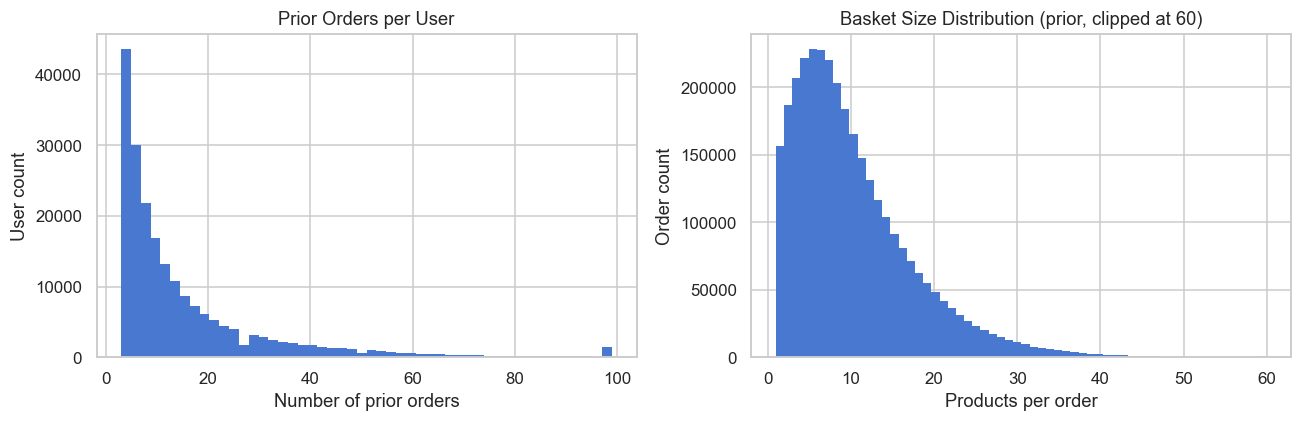

Median basket size: 8.0  |  Mean: 10.09


In [4]:
# Orders per user (prior only)
orders_per_user = prior_orders.groupby('user_id')['order_id'].count()
print('Orders per user (prior):')
print(orders_per_user.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(orders_per_user, bins=50, edgecolor='none')
axes[0].set_title('Prior Orders per User')
axes[0].set_xlabel('Number of prior orders')
axes[0].set_ylabel('User count')

# Basket size (products per order)
basket_size = prior.groupby('order_id')['product_id'].count()
axes[1].hist(basket_size.clip(upper=60), bins=60, edgecolor='none')
axes[1].set_title('Basket Size Distribution (prior, clipped at 60)')
axes[1].set_xlabel('Products per order')
axes[1].set_ylabel('Order count')

plt.tight_layout()
plt.savefig(RESULTS / 'eda_orders_baskets.png', bbox_inches='tight')
plt.show()
print(f'Median basket size: {basket_size.median():.1f}  |  Mean: {basket_size.mean():.2f}')

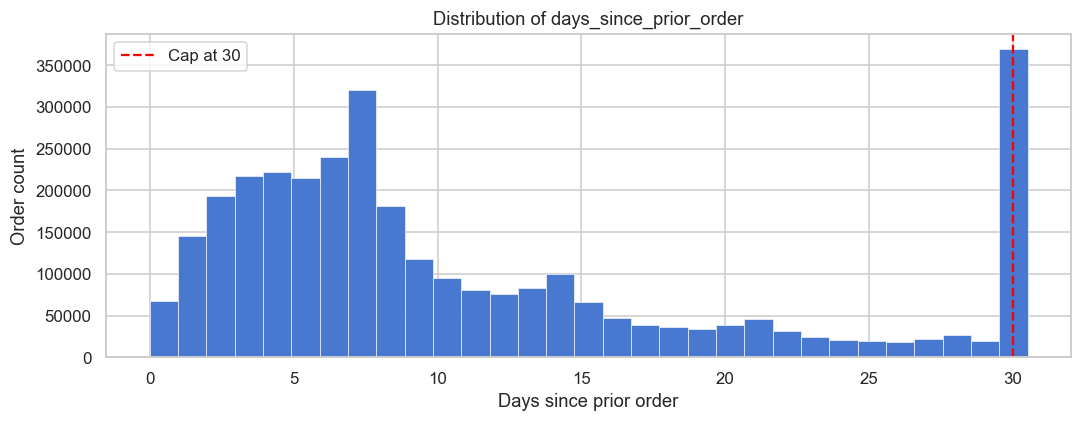

Orders with days_since_prior == 29: 19,191
Orders with days_since_prior == 30: 369,323 (11.5%)


In [5]:
# days_since_prior_order — expect spike at 30 (Instacart cap)
dspo = orders['days_since_prior_order'].dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(dspo, bins=31, range=(0, 30.5), edgecolor='white', linewidth=0.4)
ax.axvline(30, color='red', linestyle='--', label='Cap at 30')
ax.set_title('Distribution of days_since_prior_order')
ax.set_xlabel('Days since prior order')
ax.set_ylabel('Order count')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / 'eda_days_since_prior.png', bbox_inches='tight')
plt.show()

day_counts = dspo.value_counts().sort_index()
count_29 = int(day_counts.get(29.0, 0))
count_30 = int(day_counts.get(30.0, 0))
capped_frac = count_30 / len(dspo)
print(f'Orders with days_since_prior == 29: {count_29:,}')
print(f'Orders with days_since_prior == 30: {count_30:,} ({capped_frac:.1%})')
assert count_30 > count_29 * 10, 'Expected a visible 30-day cap spike.'

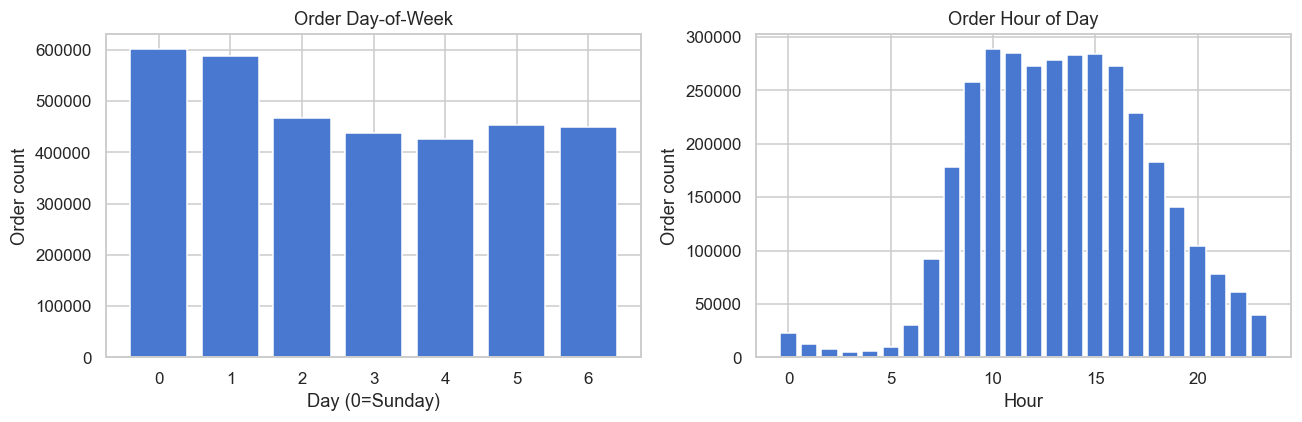

In [6]:
# Day-of-week and hour-of-day distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

dow_counts = orders['order_dow'].value_counts().sort_index()
axes[0].bar(dow_counts.index, dow_counts.values)
axes[0].set_title('Order Day-of-Week')
axes[0].set_xlabel('Day (0=Sunday)')
axes[0].set_ylabel('Order count')
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(1))

hour_counts = orders['order_hour_of_day'].value_counts().sort_index()
axes[1].bar(hour_counts.index, hour_counts.values)
axes[1].set_title('Order Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Order count')

plt.tight_layout()
plt.savefig(RESULTS / 'eda_dow_hour.png', bbox_inches='tight')
plt.show()

In [7]:
# Overall reorder rate (prior orders)
overall_reorder_rate = prior['reordered'].mean()
print(f'Overall reorder rate (prior rows): {overall_reorder_rate:.3f}')

# Reorder rate by aisle and department
prod_info = products.merge(aisles, on='aisle_id').merge(departments, on='department_id')
prior_with_info = prior.merge(prod_info[['product_id', 'aisle_id', 'aisle', 'department_id', 'department']], on='product_id')

aisle_reorder = (prior_with_info.groupby(['aisle_id', 'aisle'])['reordered']
                 .agg(['mean', 'count']).reset_index()
                 .rename(columns={'mean': 'reorder_rate', 'count': 'n'}))
aisle_reorder = aisle_reorder[aisle_reorder['n'] > 1000]  # min purchases filter

dept_reorder = (prior_with_info.groupby(['department_id', 'department'])['reordered']
                .agg(['mean', 'count']).reset_index()
                .rename(columns={'mean': 'reorder_rate', 'count': 'n'}))

print('\nTop 10 aisles by reorder rate (min 1000 purchases):')
print(aisle_reorder.nlargest(10, 'reorder_rate')[['aisle', 'reorder_rate', 'n']].to_string(index=False))
print('\nBottom 10 aisles by reorder rate:')
print(aisle_reorder.nsmallest(10, 'reorder_rate')[['aisle', 'reorder_rate', 'n']].to_string(index=False))

Overall reorder rate (prior rows): 0.590



Top 10 aisles by reorder rate (min 1000 purchases):
                        aisle  reorder_rate       n
                         milk      0.781428  891015
water seltzer sparkling water      0.729593  841533
                 fresh fruits      0.718104 3642188
                         eggs      0.705366  452134
              soy lactosefree      0.692551  638253
             packaged produce      0.690734  276028
                       yogurt      0.686489 1452343
                        cream      0.685046  318002
                        bread      0.670168  584834
                 refrigerated      0.663302  575881

Bottom 10 aisles by reorder rate:
                aisle  reorder_rate      n
    spices seasonings      0.152391 212092
baking supplies decor      0.167229  23692
            first aid      0.194812  10872
     kitchen supplies      0.195377   9172
               beauty      0.212062   6168
         eye ear care      0.217294   8974
     cold flu allergy      0.236215  26

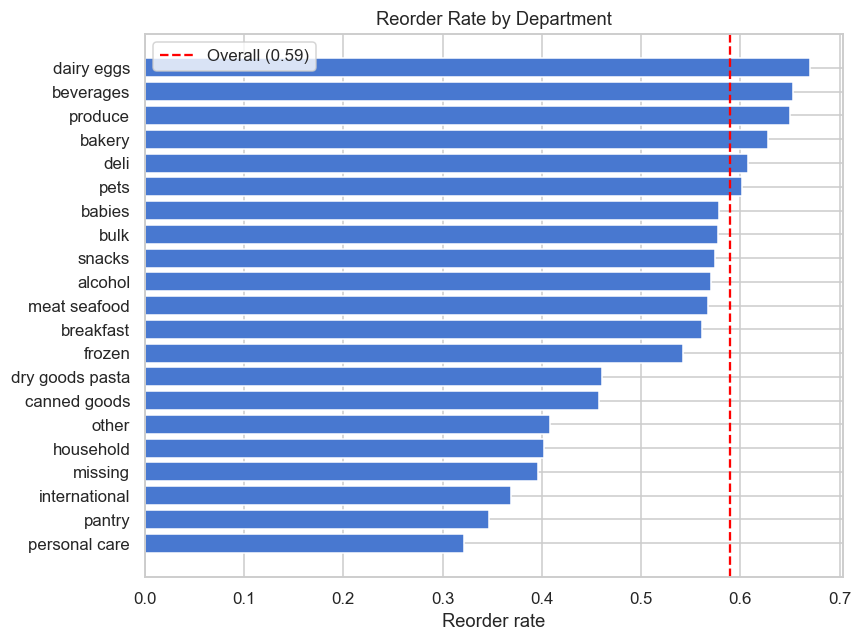

In [8]:
# Department reorder rates
dept_reorder_sorted = dept_reorder.sort_values('reorder_rate', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(dept_reorder_sorted['department'], dept_reorder_sorted['reorder_rate'])
ax.axvline(overall_reorder_rate, color='red', linestyle='--', label=f'Overall ({overall_reorder_rate:.2f})')
ax.set_title('Reorder Rate by Department')
ax.set_xlabel('Reorder rate')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / 'eda_dept_reorder_rate.png', bbox_inches='tight')
plt.show()

## 2.2  Target Variable Analysis

In [9]:
# Build (user, product) label table from train orders
# Label = 1 if product appears in user's train order
train_order_users = train_orders[['order_id', 'user_id']].copy()

# All (user, product) pairs where product was bought in prior by users
# whose next order is labeled in the official Kaggle train split.
train_user_ids = set(train_orders['user_id'])
prior_up = (prior.merge(prior_orders[['order_id', 'user_id']], on='order_id')
            [['user_id', 'product_id']].drop_duplicates())
prior_up = prior_up[prior_up['user_id'].isin(train_user_ids)]
print(f'Unique (user, product) pairs for labeled train users: {len(prior_up):,}')

# Products in train order per user
train_products = train.merge(train_order_users, on='order_id')[['user_id', 'product_id']]
train_products['label'] = 1

# Join labels onto prior pairs
labels = prior_up.merge(train_products, on=['user_id', 'product_id'], how='left')
labels['label'] = labels['label'].fillna(0).astype(int)

pos_rate = labels['label'].mean()
print(f'Positive rate (reordered): {pos_rate:.3f}')
print(f'Negative rate             : {1-pos_rate:.3f}')
print(f'Total (user,product) rows : {len(labels):,}')

Unique (user, product) pairs for labeled train users: 8,474,661


Positive rate (reordered): 0.098
Negative rate             : 0.902
Total (user,product) rows : 8,474,661


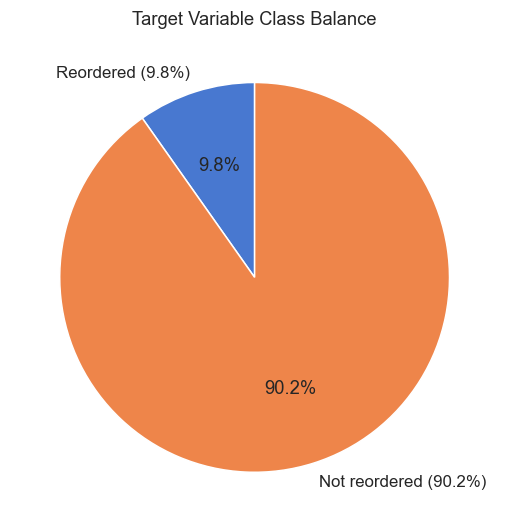

In [10]:
# Class balance pie
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie([pos_rate, 1-pos_rate],
       labels=[f'Reordered ({pos_rate:.1%})', f'Not reordered ({1-pos_rate:.1%})'],
       autopct='%1.1f%%', startangle=90)
ax.set_title('Target Variable Class Balance')
plt.tight_layout()
plt.savefig(RESULTS / 'eda_class_balance.png', bbox_inches='tight')
plt.show()

Reorder rate by user activity tier:
               reorder_rate  n_pairs
activity_tier                       
low (1-5)             0.159  1051233
medium (6-15)         0.116  2722918
high (16-30)          0.086  2163539
power (31+)           0.063  2536971


/var/folders/bc/w9w58rrd3cz088zbkzdnd8mm0000gn/T/ipykernel_76706/3806243670.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_pos = labels_with_activity.groupby('activity_tier')['label'].agg(['mean', 'count'])


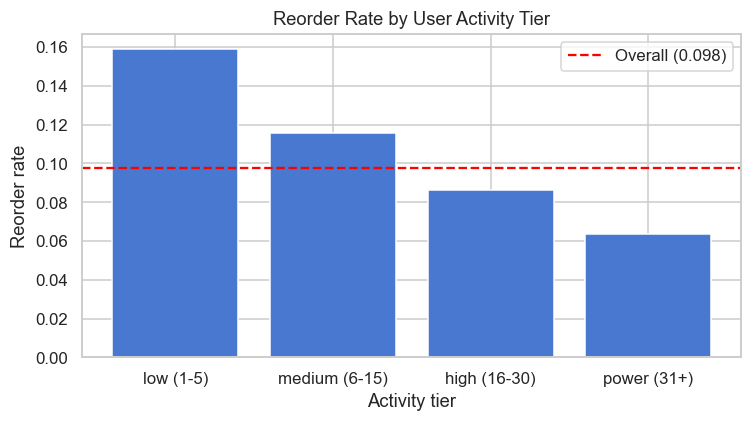

In [11]:
# Does positive rate vary by user activity level?
user_order_counts = prior_orders.groupby('user_id')['order_id'].count().rename('n_prior_orders')
labels_with_activity = labels.merge(user_order_counts, on='user_id')

labels_with_activity['activity_tier'] = pd.cut(
    labels_with_activity['n_prior_orders'],
    bins=[0, 5, 15, 30, 100],
    labels=['low (1-5)', 'medium (6-15)', 'high (16-30)', 'power (31+)']
)

tier_pos = labels_with_activity.groupby('activity_tier')['label'].agg(['mean', 'count'])
tier_pos.columns = ['reorder_rate', 'n_pairs']
print('Reorder rate by user activity tier:')
print(tier_pos.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(tier_pos.index.astype(str), tier_pos['reorder_rate'])
ax.axhline(pos_rate, color='red', linestyle='--', label=f'Overall ({pos_rate:.3f})')
ax.set_title('Reorder Rate by User Activity Tier')
ax.set_xlabel('Activity tier')
ax.set_ylabel('Reorder rate')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / 'eda_reorder_by_activity.png', bbox_inches='tight')
plt.show()

In [12]:
# Positive rate by product popularity
prod_purchase_counts = prior.groupby('product_id')['order_id'].count().rename('n_purchases')
labels_with_pop = labels.merge(prod_purchase_counts, on='product_id')

labels_with_pop['pop_tier'] = pd.cut(
    labels_with_pop['n_purchases'],
    bins=[0, 10, 100, 1000, labels_with_pop['n_purchases'].max()],
    labels=['rare (1-10)', 'niche (11-100)', 'popular (101-1000)', 'very popular (1000+)']
)

pop_pos = labels_with_pop.groupby('pop_tier')['label'].agg(['mean', 'count'])
pop_pos.columns = ['reorder_rate', 'n_pairs']
print('Reorder rate by product popularity tier:')
print(pop_pos.round(3))

Reorder rate by product popularity tier:
                      reorder_rate  n_pairs
pop_tier                                   
rare (1-10)                  0.033    26216
niche (11-100)               0.049   344349
popular (101-1000)           0.066  1682141
very popular (1000+)         0.109  6421955


/var/folders/bc/w9w58rrd3cz088zbkzdnd8mm0000gn/T/ipykernel_76706/231936254.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pop_pos = labels_with_pop.groupby('pop_tier')['label'].agg(['mean', 'count'])


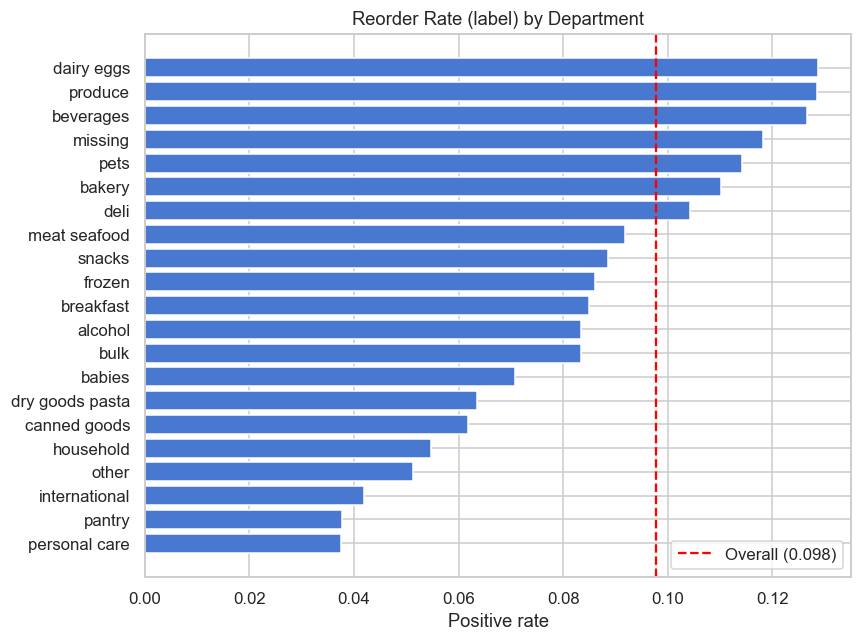

In [13]:
# Positive rate by department
prod_dept = prod_info[['product_id', 'department']]
labels_with_dept = labels.merge(prod_dept, on='product_id')
dept_label_rate = labels_with_dept.groupby('department')['label'].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(dept_label_rate.index, dept_label_rate.values)
ax.axvline(pos_rate, color='red', linestyle='--', label=f'Overall ({pos_rate:.3f})')
ax.set_title('Reorder Rate (label) by Department')
ax.set_xlabel('Positive rate')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / 'eda_label_by_dept.png', bbox_inches='tight')
plt.show()

## 2.3  Cold-start and Edge Cases

In [14]:
# Cold-start users: fewer than 5 prior orders
cold_start_users = user_order_counts[user_order_counts < 5].index
print(f'Cold-start users (<5 prior orders): {len(cold_start_users):,}  '
      f'({len(cold_start_users)/n_users:.1%} of all users)')

cold_labels = labels[labels['user_id'].isin(cold_start_users)]
warm_labels = labels[~labels['user_id'].isin(cold_start_users)]
print(f'Cold-start positive rate  : {cold_labels["label"].mean():.3f}')
print(f'Warm user positive rate   : {warm_labels["label"].mean():.3f}')

Cold-start users (<5 prior orders): 43,576  (21.1% of all users)
Cold-start positive rate  : 0.165
Warm user positive rate   : 0.092


In [15]:
# Single-purchase products: user bought this product exactly once
up_purchase_count = (prior.merge(prior_orders[['order_id', 'user_id']], on='order_id')
                     .groupby(['user_id', 'product_id'])['order_id'].count()
                     .rename('up_purchase_count').reset_index())

single_purchase_pairs = up_purchase_count[up_purchase_count['up_purchase_count'] == 1]
print(f'Single-purchase (user,product) pairs: {len(single_purchase_pairs):,}  '
      f'({len(single_purchase_pairs)/len(labels):.1%} of all pairs)')

single_labels = labels.merge(
    single_purchase_pairs[['user_id', 'product_id']],
    on=['user_id', 'product_id']
)
print(f'Single-purchase positive rate: {single_labels["label"].mean():.3f}')
print(f'(vs overall: {pos_rate:.3f})')

Single-purchase (user,product) pairs: 7,982,695  (94.2% of all pairs)


Single-purchase positive rate: 0.047
(vs overall: 0.098)


In [16]:
# "None" cases: users whose train order has NO reorders at all
# i.e., none of their train products appear in their prior purchases
train_users_with_reorders = (
    labels[labels['label'] == 1]['user_id'].unique()
)
all_train_users = train_order_users['user_id'].unique()
none_users = set(all_train_users) - set(train_users_with_reorders)

print(f'Train users total             : {len(all_train_users):,}')
print(f'Users with >=1 reorder (train): {len(train_users_with_reorders):,}')
print(f'"None" users (no reorders)     : {len(none_users):,}  '
      f'({len(none_users)/len(all_train_users):.1%})')

Train users total             : 131,209
Users with >=1 reorder (train): 122,607
"None" users (no reorders)     : 8,602  (6.6%)


In [17]:
# High-variance aisles: std dev of per-product reorder rates
product_reorder_rate = prior.groupby('product_id')['reordered'].mean()
prod_aisle = prod_info[['product_id', 'aisle_id', 'aisle']]
prod_rates = prod_aisle.merge(product_reorder_rate.rename('reorder_rate'), on='product_id')

aisle_variance = (prod_rates.groupby(['aisle_id', 'aisle'])['reorder_rate']
                  .agg(['std', 'count'])
                  .rename(columns={'std': 'rate_std', 'count': 'n_products'})
                  .dropna()
                  .query('n_products >= 5')
                  .sort_values('rate_std', ascending=False))

print('Top 10 highest-variance aisles (std dev of product reorder rates):')
print(aisle_variance.head(10)[['rate_std', 'n_products']].to_string())
print('\nTop 10 lowest-variance aisles:')
print(aisle_variance.tail(10)[['rate_std', 'n_products']].to_string())

Top 10 highest-variance aisles (std dev of product reorder rates):
                                     rate_std  n_products
aisle_id aisle                                           
124      spirits                     0.219101         195
33       kosher foods                0.218555         169
27       beers coolers               0.218283         385
84       milk                        0.214195         243
94       tea                         0.213880         894
62       white wines                 0.213085         147
28       red wines                   0.211007         232
45       candy chocolate             0.207219        1246
134      specialty wines champagnes  0.203293          95
8        bakery desserts             0.202997         297

Top 10 lowest-variance aisles:
                                rate_std  n_products
aisle_id aisle                                      
72       condiments             0.139163         466
60       trash bags liners      0.138814      

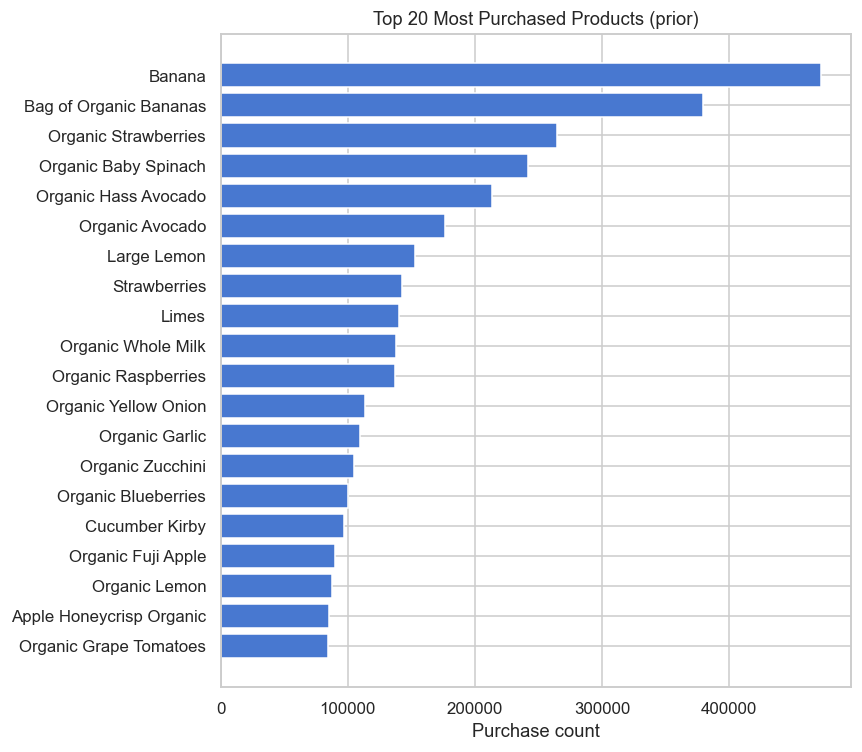

In [18]:
# Most purchased products overall
top_products = (prior.merge(products[['product_id', 'product_name']], on='product_id')
                .groupby('product_name')['order_id'].count()
                .nlargest(20)
                .sort_values())

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top_products.index, top_products.values)
ax.set_title('Top 20 Most Purchased Products (prior)')
ax.set_xlabel('Purchase count')
plt.tight_layout()
plt.savefig(RESULTS / 'eda_top_products.png', bbox_inches='tight')
plt.show()

## Summary: EDA Findings

| Finding | Value |
|---|---|
| Users | ~206K |
| Train orders (labelled) | ~131K |
| Labeled (user, product) candidate pairs | 8.47M |
| Basket-level reorder rate | 58.97% |
| Task positive class rate | 9.78% |
| Cold-start users (<5 prior) | see above |
| Single-purchase pairs | see above |
| None users | see above |

Key observations:
- `days_since_prior_order` has a visible spike at 30 (Instacart cap) — noted for feature construction
- Basket-level reorder rate (~58.97%) and task positive class rate (~9.78%) use different denominators; the supervised label table must exclude unlabeled Kaggle test users
- Power users have slightly higher reorder rates
- Personal care / household departments have notably lower reorder rates than produce / dairy
- High-variance aisles (snacks, treats) will be used as a subgroup in Phase 5 error analysis

In [19]:
# Save subgroup definitions for Phase 5
import json

cold_start_user_ids = [int(x) for x in cold_start_users]
none_user_ids = [int(x) for x in none_users]
high_variance_aisle_ids = [int(x) for x in aisle_variance.head(20).index.get_level_values('aisle_id')]

subgroups = {
    'cold_start_users': cold_start_user_ids,
    'none_users': none_user_ids,
    'high_variance_aisle_ids': high_variance_aisle_ids,
}

with open(RESULTS / 'subgroup_definitions.json', 'w') as f:
    json.dump(subgroups, f)

# Save single-purchase pairs separately (large)
single_purchase_pairs[['user_id', 'product_id']].to_parquet(
    RESULTS / 'single_purchase_pairs.parquet', index=False
)

# Save up_purchase_count for use in features.py
up_purchase_count.to_parquet(
    Path('../data/processed') / 'up_purchase_count.parquet', index=False
)

print('Subgroup definitions saved to results/')

Subgroup definitions saved to results/
